In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, norm, probplot, skew, kurtosis
from scipy.stats import skew, kurtosis, boxcox
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load Dataset

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Muhanad-husn/Sleep-Health-and-Lifestyle/refs/heads/main/data.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


# Data Transformation 
# Q.1) Analyze the shape of the heart rate distribution, identify outliers, and determine skewness and kurtosis. Apply a logarithmic transformation and report the adjusted shape, outliers, skewness, and kurtosis. 

 





In [5]:
heart_rate = df["Heart Rate"]

print("Original Distribution")

print("Shape:", heart_rate.shape)
print("Skewness:", skew(heart_rate))
print("Kurtosis:", kurtosis(heart_rate))

# Detect Outliers using IQR
Q1 = heart_rate.quantile(0.25)
Q3 = heart_rate.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = heart_rate[(heart_rate < lower) | (heart_rate > upper)]
print("Outliers:", len(outliers))

Original Distribution
Shape: (374,)
Skewness: 1.2199056700731632
Kurtosis: 2.240001297802327
Outliers: 15


Skewness: 0.996234142573339
Kurtosis: 1.50849640907703
Shape: (374,)


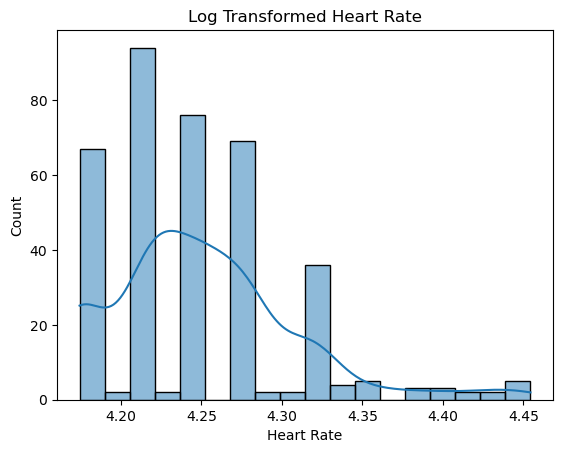

In [7]:
# Log Transformation
log = np.log(heart_rate)
print("Skewness:", skew(log))
print("Kurtosis:", kurtosis(log))
print("Shape:", heart_rate.shape)

# Plot
sns.histplot(log, kde=True)
plt.title("Log Transformed Heart Rate")
plt.show()

#
-----

# Q.2) Analyze the heart rate distribution, identify outliers, and determine skewness and kurtosis. Apply a Box-Cox transformation and report the adjusted values.

Original Skewness: 1.2199056700731632
Original Kurtosis: 2.240001297802327

Lambda Value: -5.521577841283215
Skewness After Box-Cox: 0.03890615638370502
Kurtosis After Box-Cox: -0.4204429716549205
Outliers After Transformation: 7


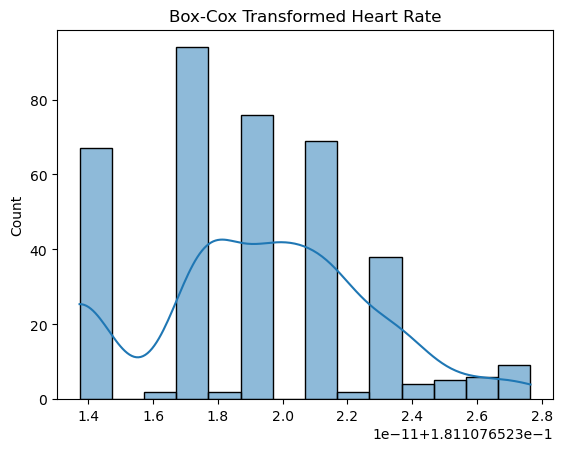

In [8]:
heart_rate = df["Heart Rate"]

print("Original Skewness:", skew(heart_rate))
print("Original Kurtosis:", kurtosis(heart_rate))

# Box-Cox transformation
boxcox_hr, lam = boxcox(heart_rate)

print("\nLambda Value:", lam)
print("Skewness After Box-Cox:", skew(boxcox_hr))
print("Kurtosis After Box-Cox:", kurtosis(boxcox_hr))

# Outliers
Q1 = np.percentile(boxcox_hr, 25)
Q3 = np.percentile(boxcox_hr, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = boxcox_hr[(boxcox_hr < lower) | (boxcox_hr > upper)]
print("Outliers After Transformation:", len(outliers))

sns.histplot(boxcox_hr, kde=True)
plt.title("Box-Cox Transformed Heart Rate")
plt.show()

# 
-----

# Q.3) Analyze the heart rate distribution, identify outliers, and determine skewness and kurtosis. Apply a square root transformation and report the adjusted values. 

Skewness After Square Root: 1.1060582251238966
Kurtosis After Square Root: 1.8551932054604725
Outliers After Transformation: 15


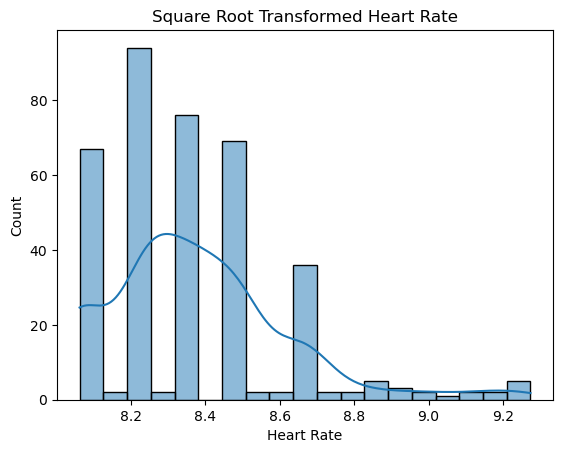

In [10]:
heart_rate = df["Heart Rate"]

sqrt_hr = np.sqrt(heart_rate)

print("Skewness After Square Root:", skew(sqrt_hr))
print("Kurtosis After Square Root:", kurtosis(sqrt_hr))

# Outliers
Q1 = np.percentile(sqrt_hr, 25)
Q3 = np.percentile(sqrt_hr, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = sqrt_hr[(sqrt_hr < lower) | (sqrt_hr > upper)]
print("Outliers After Transformation:", len(outliers))

sns.histplot(sqrt_hr, kde=True)
plt.title("Square Root Transformed Heart Rate")
plt.show()

#

#
------

# Scaling 
# Q.4) Compare the distributions of heart rate and daily steps using Min-Max Scaling and summarize observations. 

   Heart Rate  Daily Steps
0    0.571429     0.171429
1    0.476190     1.000000
2    0.476190     1.000000
3    0.952381     0.000000
4    0.952381     0.000000


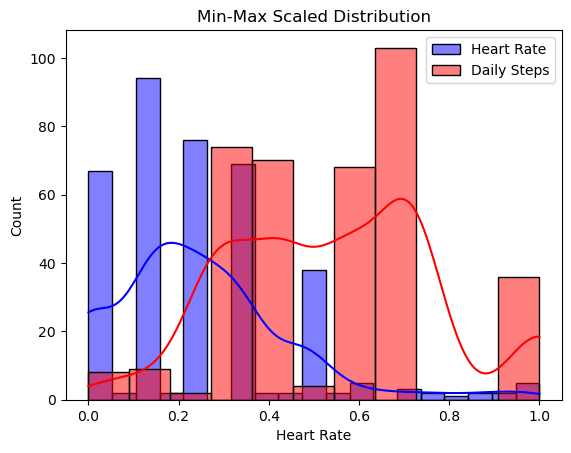

In [12]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[["Heart Rate","Daily Steps"]])

scaled_df = pd.DataFrame(scaled_data, columns=["Heart Rate","Daily Steps"])

print(scaled_df.head())

sns.histplot(scaled_df["Heart Rate"], color="blue", label="Heart Rate", kde=True)
sns.histplot(scaled_df["Daily Steps"], color="red", label="Daily Steps", kde=True)

plt.legend()
plt.title("Min-Max Scaled Distribution")
plt.show()

##
------

# Q.5) Compare the distributions of heart rate and daily steps using Standard Scaling and summarize observations. 

   Heart Rate  Daily Steps
0    1.654719    -1.619584
1    1.170474     1.970077
2    1.170474     1.970077
3    3.591698    -2.362273
4    3.591698    -2.362273


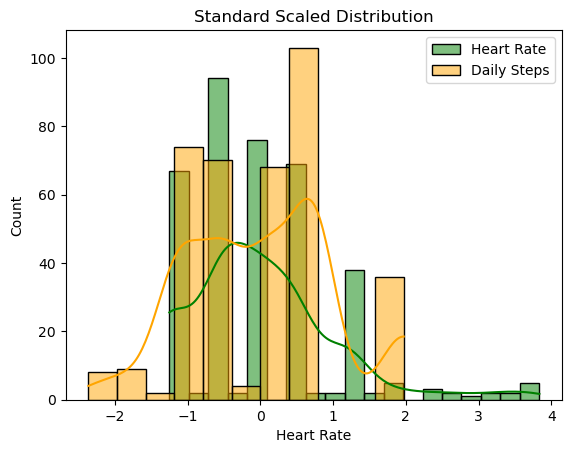

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[["Heart Rate","Daily Steps"]])

scaled_df = pd.DataFrame(scaled_data, columns=["Heart Rate","Daily Steps"])

print(scaled_df.head())

sns.histplot(scaled_df["Heart Rate"], color="green", label="Heart Rate", kde=True)
sns.histplot(scaled_df["Daily Steps"], color="orange", label="Daily Steps", kde=True)

plt.legend()
plt.title("Standard Scaled Distribution")
plt.show()

#
-----